In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.cluster import KMeans
from clustering_helpers import load_images_as_vectors, extract_true_labels, evaluate_k_range, plot_evaluation_metrics, perform_kmeans_clustering, compute_clustering_metrics, plot_clusters_scatter 

In [80]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [81]:
from datasets import load_dataset
import os

ds = load_dataset("clip-benchmark/wds_vtab-caltech101", split="test")

In [82]:
print(ds[0].keys())

dict_keys(['__key__', '__url__', 'cls', 'webp'])


In [83]:
img_key = "webp" if "webp" in ds[0] else "jpg"

out_dir = "my_photos"
os.makedirs(out_dir, exist_ok=True)

In [84]:
import random
random.seed(0)
labels_all = ds["cls"]
unique_labels = sorted(set(labels_all))
chosen_classes = random.sample(unique_labels, 12)

count = 0
per_class_budget = 15
seen_per_class = {c: 0 for c in chosen_classes}

for i, ex in enumerate(ds):
    c = ex["cls"]
    if c in chosen_classes and seen_per_class[c] < per_class_budget:
        img = ex[img_key]
        fname = f"class{c:03d}_{seen_per_class[c]:03d}.jpg"
        img.convert("RGB").save(os.path.join(out_dir, fname))
        seen_per_class[c] += 1
        count += 1
    if count >= 180:
        break

print(f"Saved {count} images to {out_dir}/")

Saved 153 images to my_photos/


In [85]:
raw_vectors, filenames = load_images_as_vectors("my_photos")
print(f"Raw pixel vectors shape: {raw_vectors.shape}")

Raw pixel vectors shape: (306, 12288)


In [86]:
true_labels = extract_true_labels(filenames)

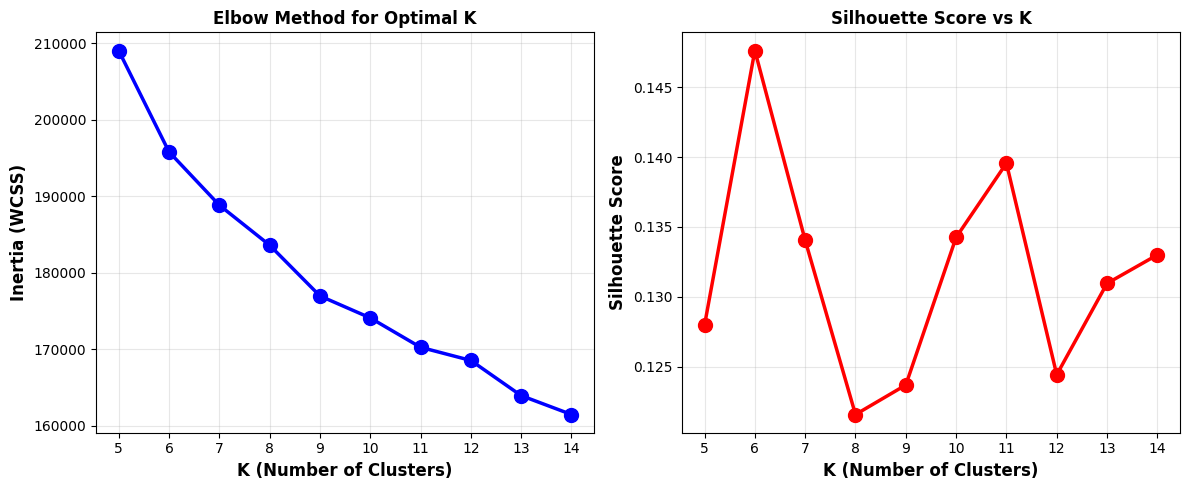

In [87]:
eval_raw = evaluate_k_range(raw_vectors.astype(np.float32), range(5, 15))
plot_evaluation_metrics(eval_raw)

K = 6 was chosen because it has the highest silhouette score, indicating the best-separated and most cohesive clusters among the tested values. The elbow point is around K = 9, but it's not very clear.

In [88]:
km_raw, raw_labels = perform_kmeans_clustering(raw_vectors.astype(np.float32), n_clusters=6)
metrics_raw = compute_clustering_metrics(true_labels, raw_labels, verbose=True)
print("\n✓ Raw pixel clustering complete")
print(f"  Cluster sizes: {np.bincount(raw_labels)}")

ARI: 0.122  |  AMI: 0.262

✓ Raw pixel clustering complete
  Cluster sizes: [112  14  76  40  38  26]


In [89]:
embeddings_data = np.load("my_photos_clip.npz")
embeddings = embeddings_data["embeddings"]
print(f"Loaded CLIP embeddings: {embeddings.shape}")

Loaded CLIP embeddings: (153, 512)


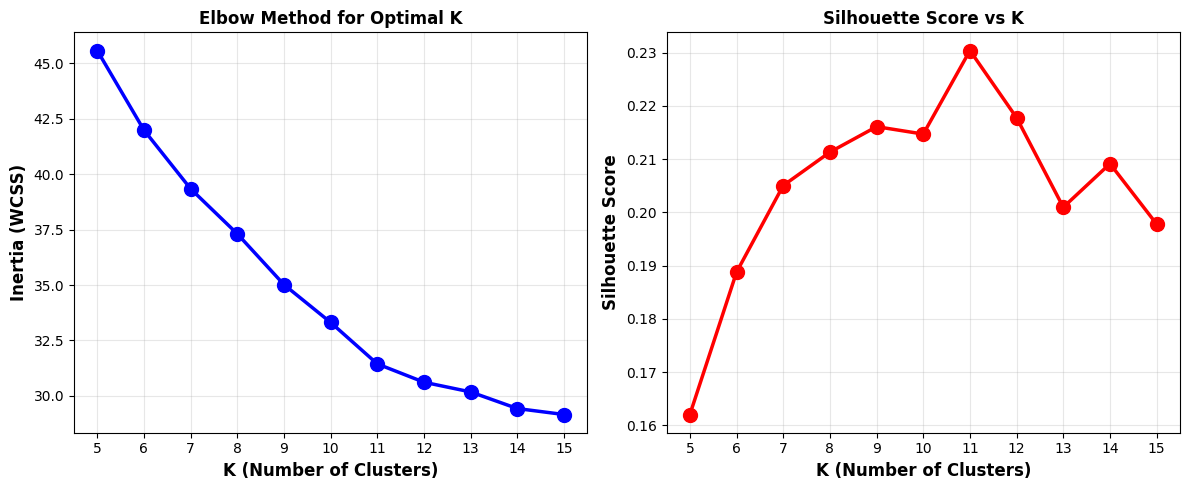

In [90]:
eval_embed = evaluate_k_range(embeddings, range(5, 16))
plot_evaluation_metrics(eval_embed)

K=11 was selected because it has the maximum silhouette score, indicating the best cluster separation. This choice is validated by the elbow method, where K=11 marks the point beyond which increasing K produces minimal changes in inertia, suggesting no significant improvement in clustering quality.

In [91]:
# Align image files with the number of embeddings
image_files_aligned = filenames[:embeddings.shape[0]]

# Create true labels only for the aligned images
true_labels = np.array([
    int(f.split('_')[0].replace('class', ''))
    for f in image_files_aligned
])

In [92]:
best_k = eval_embed['k_range'][np.argmax(eval_embed['silhouette_scores'])]
print(f"Optimal K selected: {best_k} (max silhouette score)")

km_embed, embed_labels = perform_kmeans_clustering(embeddings, n_clusters=best_k)

Optimal K selected: 11 (max silhouette score)


In [99]:
metrics_embed = compute_clustering_metrics(true_labels, embed_labels, verbose=True)
print(f"\n✓ CLIP embedding clustering complete")
print(f"  Cluster sizes: {np.bincount(embed_labels)}")

ARI: 0.972  |  AMI: 0.972

✓ CLIP embedding clustering complete
  Cluster sizes: [15 15  9 12 15 15 15 15 12 15 15]


Dimensionality reduction for visualization

In [93]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

tsne = TSNE(n_components=2, random_state=42)
tsne_coords = tsne.fit_transform(embeddings)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(embeddings)

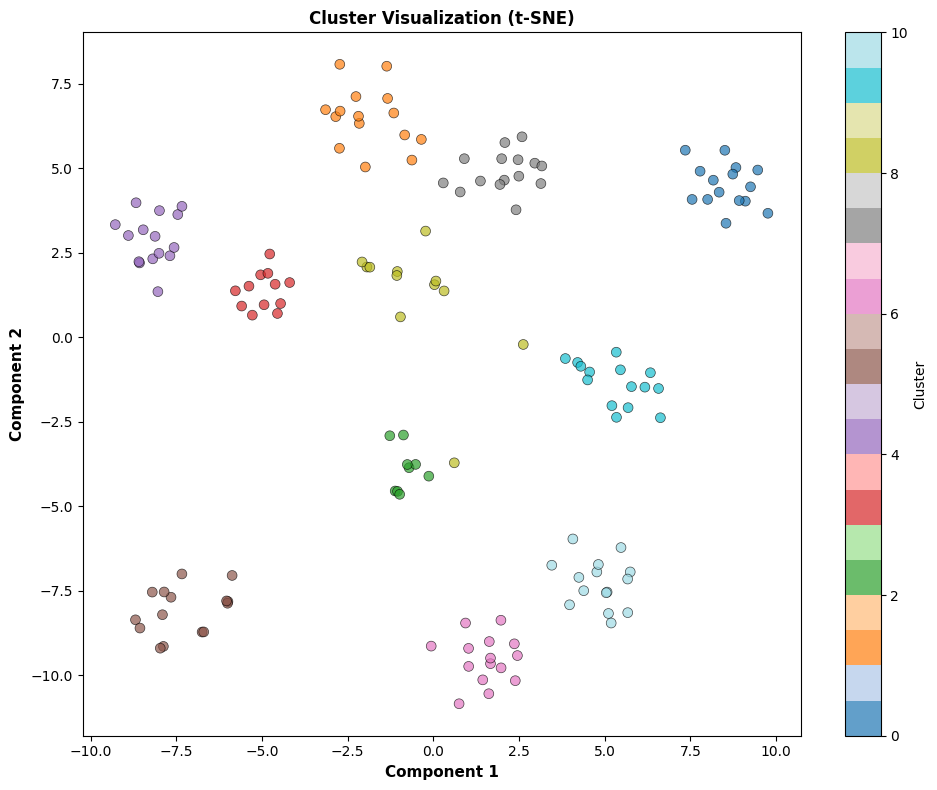

In [94]:
plot_clusters_scatter(tsne_coords, embed_labels, method_name='t-SNE', figsize=(10, 8))

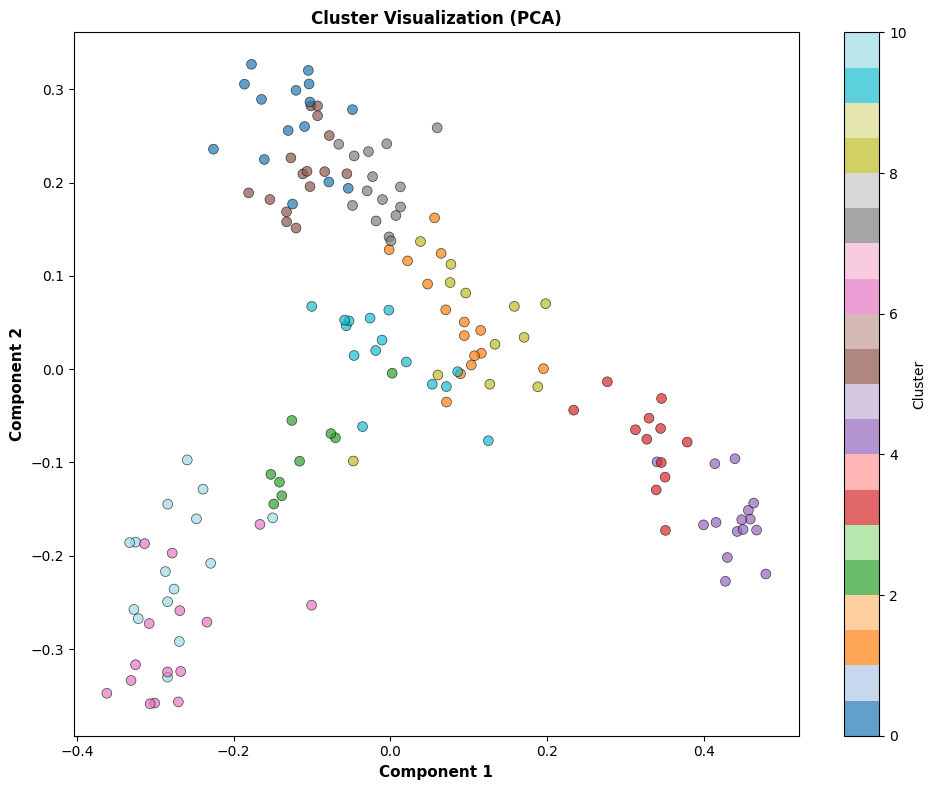

In [95]:
plot_clusters_scatter(pca_coords, embed_labels, method_name='PCA', figsize=(10, 8))

In [96]:
pip install plotly

You should consider upgrading via the '/Users/lusine/Documents/ML-Projects/Semantic_Image_Clustering/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [97]:
from photo_map import make_photo_map

image_bytes = [
    (Path("my_photos") / f).read_bytes()
    for f in filenames[:embeddings.shape[0]]
]

make_photo_map(
    xy=tsne_coords,
    jpegs=image_bytes,
    groups=embed_labels,
    title="CLIP Embeddings - t-SNE Clusters"
)

PosixPath('photo_map.html')

Conclusion

The results show that embeddings provide a much better representation for semantic image clustering than raw pixel values. So embedding-based representation captures the semantic similarity between images much more effectively.